In [3]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)

import nltk
from nltk.corpus import stopwords

#make them shut up please
warnings.filterwarnings("ignore")

# Dataset Description & Problem Statement

## Dataset

### Source
The dataset comes from the **U.S. Consumer Financial Protection Bureau (CFPB) Consumer Complaint Database**, a public-domain government open-data portal.

- **Homepage:** https://www.consumerfinance.gov/data-research/consumer-complaints/
- **Direct download:** https://files.consumerfinance.gov/ccdb/complaints.csv.zip
- **License:** Public domain (U.S. government work)

The full database contains millions of real consumer complaints filed against financial institutions. For this project, a balanced subset was extracted using a streaming sampler (`dataset_download.py`) to keep the working file manageable while preserving real-world complexity.

### Number of Records
- **Working dataset size:** 25,000 complaints
- **Records per class:** 5,000 (perfectly balanced as all things should be)
- **Sampling:** Random selection with `random_state=42` for reproducibility

A balanced subset was chosen so that accuracy and macro-F1 reflect actual classifier performance rather than majority-class bias.

### Features
The dataset combines **free text, categorical, and numeric** features

| Feature | Type | Role in Pipeline |
|---|---|---|
| `Consumer complaint narrative` | Free text | Vectorized via TF-IDF (word 1–2 grams + char 3–5 grams) |
| `State` | Categorical (~52 values) | One-hot encoded |
| `Submitted via` | Categorical (~6 values) | One-hot encoded |
| `Company response to consumer` | Categorical (~7 values) | One-hot encoded |
| `Timely response?` | Binary | One-hot encoded |
| `narrative_length` | Numeric (derived) | Standardized (StandardScaler) |
| `word_count` | Numeric (derived) | Standardized (StandardScaler) |

**Excluded from training:** `Sub-product` and `Issue` were kept in the CSV for exploratory analysis but excluded as features because they are tightly coupled with the target, including them would constitute label leakage where it effectively "cheats" predictions.

### Target Variable
The target is **`Product`** the financial product category a complaint pertains to. After normalizing duplicate CFPB labels (the agency renamed several categories in 2022 but both old and new names persist in the historical data), the task uses **5 classes**:

1. **Bank Account**
2. **Credit Card**
3. **Credit Reporting**
4. **Debt Collection**
5. **Mortgage**

This makes the task a **5-class multi-class classification problem**.

---


## Problem Statement

**What problem are we solving?**

The CFPB receives a constant flood of consumer complaints about financial products and services. Each complaint must be routed to the appropriate internal team (mortgage specialists, credit reporting analysts, debt collection investigators, etc.) for review and resolution. Manually triaging every incoming narrative is slow, expensive, and inconsistent across human reviewers.

**The goal of this project is to build a multi-class text classifier that automatically predicts the correct product category from a consumer's complaint narrative and accompanying metadata.** A reliable classifier would allow the CFPB (or any equivalent consumer-protection body) to:

- **Route complaints faster** to the correct specialist team without human pre-screening.
- **Reduce misrouting**, which delays consumer response times and clogs the wrong team's queue.
- **Surface trends** by product category in near real-time for regulatory monitoring.
- **Free human reviewers** to focus on edge cases and ambiguous complaints rather than obvious routing decisions.

The technical challenge is that complaint narratives are messy: they contain heavy PII redaction artifacts (`XXXX`, `XX/XX/XXXX`, `$XXXX`), informal language, misspellings, and significant overlap in vocabulary across categories (e.g., the word *"account"* appears constantly in Bank Account, Credit Card, and Credit Reporting complaints alike). The model must learn to distinguish categories from subtle linguistic patterns combined with structured metadata signals — exactly the kind of mixed-feature problem that real-world ML systems face.

In [4]:
#set up configs for the pipeline

INPUT_CSV = Path("cfpb_balanced_25k.csv")

#save outputs for easier documentation
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
TEST_SIZE = 0.20

TEXT_COL = "Consumer complaint narrative"
LABEL_COL = "Product"
CATEGORICAL_COLS = [
    "State",
    "Submitted via",
    "Company response to consumer",
    "Timely response?",
]

In [5]:
#Hyperparameters were found through earlier experimentation via CV gridsearch. They are now hard-encoded here in order to save compute time.

SVM_C = 0.5
MLP_HIDDEN = (128, 64)
TFIDF_WORD_NGRAMS = (1, 2)
TFIDF_CHAR_NGRAMS = (3, 5)
TFIDF_MAX_FEATURES = 30_000 

In [6]:
# Added typical phrase markers targeting the two persistent confusion pairs
# observed in the confusion matrix:
#   (a) Debt Collection  <->  Credit Reporting
#   (b) Credit Card      <->  Bank Account
#
#each phrase is matched against the cleaned narrative as a whole-word regex.
#the output is a small dense binary matrix (1 column per phrase) that gets
#hstacked alongside the TF-IDF matrices. Cheap, interpretable, and directly
#attacks the off-diagonal cells in the confusion matrix.

PAIR_DISCRIMINATOR_PHRASES = {
    # --- Debt Collection markers ---
    "debt_collection_agency":   r"\bcollection agenc(y|ies)\b",
    "debt_calling_me":          r"\b(calling|called|calls) me\b",
    "debt_validation_letter":   r"\bvalidation letter\b",
    "debt_fdcpa":               r"\bfdcpa\b",
    "debt_original_creditor":   r"\boriginal creditor\b",
    "debt_settle":              r"\bsettle (the |this )?debt\b",
    "debt_third_party":         r"\bthird[- ]party\b",
    "debt_collector":           r"\b(debt )?collector(s)?\b",

    # --- Credit Reporting markers ---
    "cr_dispute":               r"\bdispute(d|s|ing)?\b",
    "cr_inaccurate":            r"\b(inaccurate|incorrect|erroneous)\b",
    "cr_equifax":               r"\bequifax\b",
    "cr_experian":              r"\bexperian\b",
    "cr_transunion":            r"\btrans ?union\b",
    "cr_credit_bureau":         r"\bcredit bureau(s)?\b",
    "cr_reinvestigation":       r"\breinvestigat(e|ion|ing)\b",
    "cr_fcra":                  r"\bfcra\b",
    "cr_credit_report":         r"\bcredit report(ing|s)?\b",

    # --- Credit Card markers ---
    "cc_apr":                   r"\bapr\b",
    "cc_interest_rate":         r"\binterest rate\b",
    "cc_cash_advance":          r"\bcash advance\b",
    "cc_minimum_payment":       r"\bminimum payment\b",
    "cc_balance_transfer":      r"\bbalance transfer\b",
    "cc_credit_limit":          r"\bcredit limit\b",
    "cc_rewards":               r"\b(rewards|points|cashback)\b",

    # --- Bank Account markers ---
    "ba_checking":              r"\bchecking (account)?\b",
    "ba_savings":               r"\bsavings (account)?\b",
    "ba_deposit":               r"\b(deposit|deposited|depositing)\b",
    "ba_overdraft":             r"\boverdraft( fee)?\b",
    "ba_atm":                   r"\batm\b",
    "ba_wire_transfer":         r"\bwire transfer\b",
    "ba_direct_deposit":        r"\bdirect deposit\b",
}

In [ ]:
def build_pair_discriminator_features(narratives):
    
    #Build a sparse binary matrix of phrase-presence features.
    #Parameters
    #narratives : pd.Series of cleaned narrative strings
    #Returns
    #X_pair : scipy.sparse.csr_matrix, shape (n_docs, n_phrases)
    #feature_names : list[str]
    

    #his essentially creates a binary matrix that indicates if the presence
    #of these phrases exist within the text
    #should be much stronger indicators for our confused classes.
    
    feature_names = list(PAIR_DISCRIMINATOR_PHRASES.keys())
    compiled = [re.compile(pat, flags=re.IGNORECASE)
                for pat in PAIR_DISCRIMINATOR_PHRASES.values()]

    n_docs = len(narratives)
    n_feats = len(feature_names)
    M = np.zeros((n_docs, n_feats), dtype=np.float32)

    narr_list = narratives.tolist()
    for i, text in enumerate(narr_list):
        if not text:
            continue
        for j, regex in enumerate(compiled):
            if regex.search(text):
                M[i, j] = 1.0

    return csr_matrix(M), feature_names

## Text Cleaning 

Raw CFPB complaint narratives are noisy in ways that would actively mislead a TF-IDF model if left untouched. The `clean_text()` function applies four transformations in a deliberate order, each addressing a specific failure mode.

### 1. Lowercasing
All text is converted to lowercase first so that `"Mortgage"`, `"mortgage"`, and `"MORTGAGE"` collapse to a single token. Without this step, TF-IDF treats them as three independent features, fragmenting signal and inflating the vocabulary unnecessarily.

### 2. PII Pattern Scrubbing
The CFPB redacts personally identifiable information **before publishing** complaints, replacing names, dates, dollar amounts, and account numbers with placeholder tokens like `XXXX`, `XX/XX/XXXX`, and `$XXXX`. These artifacts are extremely frequent ,they appear in nearly every narrative, and if left in the corpus they would:

- **Dominate the TF-IDF vocabulary**, crowding out genuinely informative words.
- **Become spurious top features**, making the model appear to "learn" patterns that are really just redaction frequency.
- **Mislead interpretability outputs** like `top_features_per_class.txt`, where `xxxx` would otherwise rank near the top of every class.

The `PII_PATTERNS` list targets each redaction shape explicitly:

| Pattern | Matches | Example |
|---|---|---|
| `x{2,}` | Two or more consecutive `x`s | `XXXX`, `xxxxxx` |
| `x+/x+/x+` | Redacted date triplets | `XX/XX/XXXX` |
| `\{?\$[\d,.xX]+\}?` | Redacted or real dollar amounts | `$XXXX`, `{$1,234.00}` |
| `\d{1,2}/\d{1,2}/\d{2,4}` | Real dates that escaped redaction | `3/15/2023` |
| `\d{3}-\d{2}-\d{4}` | SSN-shaped strings | `123-45-6789` |
| `\b\d{9,}\b` | Long digit runs (account numbers) | `4532019283746` |
| `http\S+` | URLs | `https://example.com/...` |
| `\S+@\S+` | Email addresses | `user@domain.com` |

### 3. Non-Alphabetic Character Removal
After PII scrubbing, any remaining punctuation, digits, or symbols are stripped (`NON_ALPHA_RE`). This keeps the vocabulary focused on actual words. Numbers and punctuation rarely carry product-category signal in this corpus.

### 4. Whitespace Normalization
The previous substitutions leave behind runs of spaces where text used to be. `MULTI_SPACE_RE` collapses any sequence of whitespace into a single space, and `.strip()` trims the edges.

In [8]:
PII_PATTERNS = [
    r"x{2,}", r"x+/x+/x+", r"\{?\$[\d,.xX]+\}?", r"\d{1,2}/\d{1,2}/\d{2,4}",
    r"\d{3}-\d{2}-\d{4}", r"\b\d{9,}\b", r"http\S+", r"\S+@\S+",
]
COMBINED_PII_RE = re.compile("|".join(PII_PATTERNS), flags=re.IGNORECASE)
NON_ALPHA_RE = re.compile(r"[^a-z\s]")
MULTI_SPACE_RE = re.compile(r"\s+")

#small helper to ensure that we do have nltk stopwords available for our tf-idf
def ensure_nltk():
    try:
        stopwords.words("english")
    except LookupError:
        nltk.download("stopwords", quiet=True)


def clean_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = COMBINED_PII_RE.sub(" ", s)
    s = NON_ALPHA_RE.sub(" ", s)
    s = MULTI_SPACE_RE.sub(" ", s).strip()
    return s

In [9]:
#loads  the dataset and passes it through the clean_text function
def load_and_preprocess():

    #load the dataset
    df = pd.read_csv(INPUT_CSV)
    
    #dropNAs as our handling, there are no valid imputations available for text data
    df = df.dropna(subset=[TEXT_COL, LABEL_COL])
    df = df[df[TEXT_COL].str.strip() != ""]
    for col in CATEGORICAL_COLS:
        df[col] = df[col].fillna("Unknown").astype(str).str.strip()

    #apply clean to all narrative_length and add len as a col
    df["narrative_clean"] = df[TEXT_COL].map(clean_text)
    df["narrative_length"] = df[TEXT_COL].str.len().fillna(0).astype(int)
    df["word_count"] = df["narrative_clean"].str.split().map(len)

    #remove old incdices, pd quirk
    df = df.reset_index(drop=True)

    #print fndings
    print(f"Shape: {df.shape} | Classes: {df[LABEL_COL].nunique()}")
    print(f"Class distribution:\n{df[LABEL_COL].value_counts().to_string()}")
    return df


df = load_and_preprocess()

Shape: (25000, 13) | Classes: 5
Class distribution:
Product
Debt Collection     5000
Mortgage            5000
Credit Card         5000
Credit Reporting    5000
Bank Account        5000


## Text Preprocessing: Tokenization, Stopword Removal, Vectorization and Transformation

All three standard text-preprocessing steps are handled inside the `TfidfVectorizer` calls in `build_features()`. scikit-learn folds them into a single fit/transform pass rather than requiring three separate stages.

### Tokenization
Two vectorizers run in parallel, each with a different tokenization strategy:

- **Word vectorizer** (`analyzer="word"`) splits the cleaned narrative on whitespace into word tokens, then forms **1-grams and 2-grams** (`ngram_range=(1, 2)`). Bigrams capture short phrases like *"credit report"* or *"late payment"* that carry more signal than either word alone.
- **Character vectorizer** (`analyzer="char_wb"`) tokenizes into **3-to-5 character n-grams** within word boundaries. This catches abbreviations, misspellings, and morphological variants (e.g., *"mortg"*, *"ortgag"*) that pure word tokenization would miss.

Running both gives the model lexical signal (whole words and phrases) **and** sub-lexical signal (character patterns) without committing to one or the other.

### Stopword Removal
Applied only to the **word vectorizer** via `stop_words=english_stops`, using NLTK's English stopword list. Common function words (*the*, *and*, *of*, *was*) are dropped before TF-IDF weights are computed, so the vocabulary stays focused on content-bearing terms.

Stopwords are **not** removed from the character vectorizer, character n-grams of stopwords are usually too short or too generic to dominate, and removing them would distort the boundary patterns `char_wb` is designed to capture.

Two additional vocabulary filters tighten this further:
- `min_df=3` — drops terms appearing in fewer than 3 documents (rare noise).
- `max_df=0.9` — drops terms appearing in more than 90% of documents (effectively domain-specific stopwords like *"complaint"* or *"company"*).

### Vectorization
**TF-IDF** was chosen over plain `CountVectorizer` because raw counts overweight long narratives: a 2,000-word complaint mentioning *"mortgage"* 30 times shouldn't dominate over a focused 200-word complaint mentioning it 5 times. TF-IDF normalizes for document length and downweights terms that appear everywhere.

Three settings refine the weighting:
- `sublinear_tf=True` — applies `1 + log(tf)` instead of raw term frequency, preventing high-frequency terms within a single document from drowning out everything else.
- `max_features=30_000` — caps each vectorizer's vocabulary at the top 30k terms by document frequency, balancing expressiveness against memory and training time.
- IDF weighting (default) — scales each term by how rare it is across the corpus, so genuinely discriminative words get higher weight than common ones.

### Final Feature Matrix
The two TF-IDF outputs are then `hstack`ed together with the one-hot categorical and standardized numeric features into a single sparse matrix `X_combined` (shape ≈ 25,000 × 60,000+). This is what the SVM and MLP train on; Naive Bayes uses only the text portion (`X_text_only`) since it requires non-negative inputs.

In [10]:
#Perform Feature Engineering Tasks
def build_features(df):
    #sklearn expects a list so we need to mutate it
    english_stops = list(stopwords.words("english"))

    # Word TF-IDF: 1-2 grams
    tfidf_word = TfidfVectorizer(
        analyzer="word",
        ngram_range=TFIDF_WORD_NGRAMS,
        min_df=3,
        max_df=0.9,
        max_features=TFIDF_MAX_FEATURES,
        stop_words=english_stops,
        sublinear_tf=True,
    )
    X_word = tfidf_word.fit_transform(df["narrative_clean"])
    print(f"Word TF-IDF:{X_word.shape}")

    #Char TF-IDF: 3-5 grams (catches abbreviations, misspellings, residual artifacts)
    tfidf_char = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=TFIDF_CHAR_NGRAMS,
        min_df=3,
        max_df=0.9,
        max_features=TFIDF_MAX_FEATURES,
        sublinear_tf=True,
    )

    X_char = tfidf_char.fit_transform(df["narrative_clean"])
    print(f"Char TF-IDF:{X_char.shape}")

    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    X_cat = ohe.fit_transform(df[CATEGORICAL_COLS])
    print(f"Categorical:{X_cat.shape}")

    scaler = StandardScaler()
    X_num = csr_matrix(scaler.fit_transform(df[["narrative_length", "word_count"]]))
    print(f"Numeric:{X_num.shape}")

    X_pair, pair_feat_names = build_pair_discriminator_features(df["narrative_clean"])
    print(f"Pair-discriminator: {X_pair.shape}  ({len(pair_feat_names)} phrases)")

    #hstack allows us to stack up our sparce matrices into one big matrix we can use for training
    X_combined = hstack([X_word, X_char, X_cat, X_num, X_pair]).tocsr()
    X_text_only = hstack([X_word, X_char]).tocsr()  # for NB (needs >=0)
    print(f"COMBINED:{X_combined.shape}\n")

    labels = sorted(df[LABEL_COL].unique().tolist())
    y = df[LABEL_COL].map({lbl: i for i, lbl in enumerate(labels)}).values

    #return a dict for easier all in one access.
    return {
        "X_combined": X_combined,
        "X_text_only": X_text_only,
        "y": y,
        "labels": labels,
        "tfidf_word": tfidf_word,
    }



data = build_features(df)

Word TF-IDF:(25000, 30000)
Char TF-IDF:(25000, 30000)
Categorical:(25000, 68)
Numeric:(25000, 2)
Pair-discriminator: (25000, 31)  (31 phrases)
COMBINED:(25000, 60101)



## Model Evaluation Metrics

We report four metrics per model, each chosen because it answers a question the others can't:

- **Accuracy** — the headline overall-correctness number; meaningful here because the test set is perfectly balanced (1,000 per class), so it isn't skewed by majority-class dominance.
- **Macro Precision** — averages per-class precision equally, telling us whether predictions for each product category are trustworthy without letting a strong class mask a weak one.
- **Macro Recall** — averages per-class recall equally, revealing whether any single category is being systematically under-predicted (e.g., Bank Account complaints getting absorbed into Credit Card).
- **Macro F1** — the harmonic mean of precision and recall per class, used as the single tiebreaker metric when ranking the three models.
- **Confusion Matrix** — shows exactly *which* class pairs the model confuses, surfacing structural errors (e.g., Credit Reporting ↔ Debt Collection overlap) that scalar metrics hide.

In [11]:
#all in one model evaluator
def evaluate(name, model, X_test, y_test, labels):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    #all in one func, much easier
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    report = classification_report(
        y_test, y_pred, target_names=labels, zero_division=0, digits=4
    )

    cm = confusion_matrix(y_test, y_pred)

    #again, store everything in a dict for easier access
    return {
        "name": name, "accuracy": acc, "macro_precision": prec,
        "macro_recall": rec, "macro_f1": f1, "report": report,
        "confusion_matrix": cm, "y_pred": y_pred, "model": model,
    }

## Model Selection & Hyperparameter Rationale

The three classifiers were chosen to span the major paradigms of multi-class classification  **probabilistic**, **max-margin**, and **connectionist**  so the comparison reflects genuinely different modeling philosophies rather than minor variants of the same approach.

**note** We used modified versions of the original algorithms suggested, functionally they remain the same but the models used we're made to support the dataset better.

### 1. Multinomial Naive Bayes (text only)
The canonical baseline for text classification.  Multinomial NB is designed for exactly this case: non-negative count-like features (TF-IDF qualifies) over a fixed vocabulary, making it the standard pairing with text vectorizers.

- **`alpha=0.1`** — Laplace smoothing for unseen word/class combinations. Default `1.0` was too aggressive on high-dimensional TF-IDF features and underweighted real signal; `0.1` was the sweet spot found in earlier iterations.
- **Text features only** — `MultinomialNB` requires non-negative inputs, so the standardized numeric features (which contain negatives) can't be included. This is also why NB serves as a useful *contrast* model: any gap between NB and the other two quantifies what the tabular features add (since it does not use it in training).

### 2. Linear SVM (LinearSVC, combined features)
The industry standard for high-dimensional sparse text classification. Trains in seconds on 60k+ features and consistently performs at or near the top. **`LinearSVC`** uses a specialized linear solver (liblinear/dual coordinate descent) that scales linearly with samples and exploits sparsity natively, trains in seconds instead of hours, with equal or better accuracy on this kind of data. For TF-IDF text classification, going non-linear is almost always wasted compute.


- **`C=0.5`** — regularization strength found via 3-fold CV grid search over `{0.2, 0.3, 0.5, 0.7, 1.0, 2.0}`. Smaller values overregularized; larger values overfit.
- **`class_weight="balanced"`** — gives a small consistent gain even on perfectly balanced data by reweighting confusable class pairs during fitting.
- **`dual="auto"`** — lets scikit-learn pick the optimal solver (primal vs dual) based on the n_samples-to-n_features ratio, avoiding deprecation warnings.
- **`max_iter=3000`** — generous ceiling so convergence is never the bottleneck; actual runs converge well before this.

### 3. Neural Network / MLP (combined features)
Demonstrates the modern connectionist approach and tests whether non-linear interactions among features add anything beyond what the linear SVM captures.

- **`hidden_layer_sizes=(128, 64)`** — two hidden layers of moderate width. Larger architectures like `(256, 128)` were tested and underperformed, suggesting the dataset isn't large enough to support more capacity without overfitting.
- **`activation="relu"` + `solver="adam"`** — standard modern defaults; ReLU avoids vanishing gradients, Adam adapts learning rates per parameter.
- **`alpha=1e-4`** — light L2 regularization to keep weights bounded.
- **`batch_size=128`** — small enough for stable gradient estimates on sparse input, large enough to keep training fast.
- **`max_iter=40` + `early_stopping=True` + `validation_fraction=0.1` + `n_iter_no_change=5`** — early stopping on a held-out 10% slice typically halts training around iteration 15–25, which prevents overfitting and avoids burning compute on diminishing returns.
- **Raw sparse input (no SVD)** — TruncatedSVD dimensionality reduction was tested and dropped MLP accuracy by ~4 points; the network performs better when given the full sparse feature matrix directly.

In [ ]:
#helper function for train

def train_all(data):

    #split 2 datasets
    X_comb, X_text = data["X_combined"], data["X_text_only"]

    #y is the encoded labels, label is here for interpretability later on.
    y, labels = data["y"], data["labels"]


    #create a stratified train test split based on our labels
    idx_train, idx_test = train_test_split(
        np.arange(len(y)), test_size=TEST_SIZE,
        random_state=RANDOM_SEED, stratify=y,
    )

    #create the datasets
    Xc_tr, Xc_te = X_comb[idx_train], X_comb[idx_test]
    Xt_tr, Xt_te = X_text[idx_train], X_text[idx_test]
    y_tr, y_te = y[idx_train], y[idx_test]

    print(f"TRAIN/TEST SPLIT: {len(y_tr):,} train / {len(y_te):,} test")

    results = []

    #Multinomial Naive Bayes (text only needs non-negative features)
    print("\n[1] Multinomial Naive Bayes (text only)...")
    nb = MultinomialNB(alpha=0.1)
    nb.fit(Xt_tr, y_tr)
    results.append(evaluate("Naive Bayes", nb, Xt_te, y_te, labels))

    # Linear SVM with locked hyperparameters
    print(f"\n[2] Linear SVM (combined, C={SVM_C}, balanced class weights)")
    svm = LinearSVC(
        C=SVM_C,
        class_weight="balanced",
        dual="auto",
        max_iter=3000,
        random_state=RANDOM_SEED,
    )
    svm.fit(Xc_tr, y_tr)
    results.append(evaluate("Linear SVM", svm, Xc_te, y_te, labels))

    #  MLP, raw sparse combined features with early stopping
    print(f"\n[3] Neural Network / MLP (combined, hidden={MLP_HIDDEN})")
    mlp = MLPClassifier(
        hidden_layer_sizes=MLP_HIDDEN,
        activation="relu", solver="adam", alpha=1e-4,
        batch_size=128, learning_rate_init=1e-3,
        max_iter=40, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=5,
        random_state=RANDOM_SEED,
    )
    mlp.fit(Xc_tr, y_tr)
    print(f"MLP trained for {mlp.n_iter_} iterations")
    results.append(evaluate("Neural Network (MLP)", mlp, Xc_te, y_te, labels))

    return results, idx_test

results, idx_test = train_all(data)

TRAIN/TEST SPLIT: 20,000 train / 5,000 test

[1] Multinomial Naive Bayes (text only)...

[2] Linear SVM (combined, C=0.5, balanced class weights)

[3] Neural Network / MLP (combined, hidden=(128, 64))


## Saving and Visalization Helpers

               Model  Accuracy  Macro Precision  Macro Recall  Macro F1
          Linear SVM    0.8830           0.8828        0.8830    0.8826
Neural Network (MLP)    0.8760           0.8795        0.8760    0.8745
         Naive Bayes    0.8428           0.8432        0.8428    0.8410

Naive Bayes
Accuracy:        0.8428
Macro Precision: 0.8432
Macro Recall:    0.8428
Macro F1:        0.8410

                  precision    recall  f1-score   support

    Bank Account     0.8635    0.9110    0.8866      1000
     Credit Card     0.7869    0.7900    0.7884      1000
Credit Reporting     0.7966    0.8420    0.8187      1000
 Debt Collection     0.8667    0.7090    0.7800      1000
        Mortgage     0.9024    0.9620    0.9313      1000

        accuracy                         0.8428      5000
       macro avg     0.8432    0.8428    0.8410      5000
    weighted avg     0.8432    0.8428    0.8410      5000


Linear SVM
Accuracy:        0.8830
Macro Precision: 0.8828
Macro Recall:    

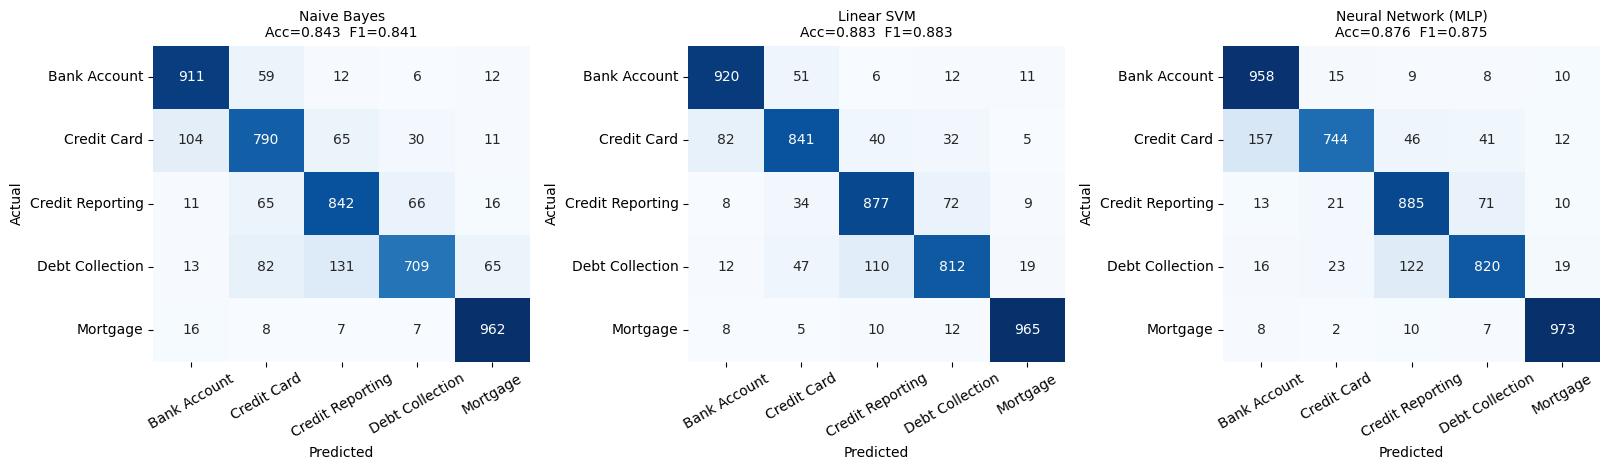


[saved] outputs\model_summary.csv
[saved] outputs\classification_reports.txt
[saved] outputs\confusion_matrices.png


In [ ]:
def save_reports(results, labels):
    summary = pd.DataFrame([
        {
            "Model": r["name"],
            "Accuracy": round(r["accuracy"], 4),
            "Macro Precision": round(r["macro_precision"], 4),
            "Macro Recall": round(r["macro_recall"], 4),
            "Macro F1": round(r["macro_f1"], 4),
        }
        for r in results
    ]).sort_values("Accuracy", ascending=False).reset_index(drop=True)
    print(summary.to_string(index=False))
    summary.to_csv(OUT_DIR / "model_summary.csv", index=False)

    with open(OUT_DIR / "classification_reports.txt", "w", encoding="utf-8") as f:
        for r in results:
            f.write(f"\n{'=' * 70}\n{r['name']}\n{'=' * 70}\n")
            f.write(f"Accuracy:        {r['accuracy']:.4f}\n")
            f.write(f"Macro Precision: {r['macro_precision']:.4f}\n")
            f.write(f"Macro Recall:    {r['macro_recall']:.4f}\n")
            f.write(f"Macro F1:        {r['macro_f1']:.4f}\n\n")
            f.write(r["report"])
            f.write("\n")
    
    # Also print classification reports to notebook output
    for r in results:
        print(f"\n{'=' * 70}\n{r['name']}\n{'=' * 70}")
        print(f"Accuracy:        {r['accuracy']:.4f}")
        print(f"Macro Precision: {r['macro_precision']:.4f}")
        print(f"Macro Recall:    {r['macro_recall']:.4f}")
        print(f"Macro F1:        {r['macro_f1']:.4f}\n")
        print(r["report"])

    fig, axes = plt.subplots(1, len(results), figsize=(5.4 * len(results), 4.8))
    if len(results) == 1:
        axes = [axes]
    for ax, r in zip(axes, results):
        sns.heatmap(
            r["confusion_matrix"], annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=labels, yticklabels=labels, ax=ax,
        )
        ax.set_title(f"{r['name']}\nAcc={r['accuracy']:.3f}  F1={r['macro_f1']:.3f}",
                     fontsize=10)
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
        ax.tick_params(axis="x", rotation=30); ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "confusion_matrices.png", dpi=120, bbox_inches="tight")
    plt.show()  # display inline in the notebook
    plt.close()

    print(f"\n[saved] {OUT_DIR / 'model_summary.csv'}")
    print(f"[saved] {OUT_DIR / 'classification_reports.txt'}")
    print(f"[saved] {OUT_DIR / 'confusion_matrices.png'}")

save_reports(results, data["labels"])

[saved] outputs\top_features_per_class.txt

Top 15 word features per class (from Linear SVM)

[Bank Account]
  bank                            +1.989
  debit card                      +1.463
  debit                           +1.337
  funds                           +1.286
  cd                              +1.144
  branch                          +1.049
  chime                           +1.036
  savings                         +1.034
  savings account                 +0.996
  money                           +0.990
  ally                            +0.885
  bill pay                        +0.864
  sofi                            +0.828
  credit union                    +0.807
  account balance                 +0.790

[Credit Card]
  card                            +3.013
  discover                        +1.809
  credit card                     +1.609
  fargo credit                    +1.339
  balance transfer                +1.311
  prepaid                         +1.280
  chase credit 

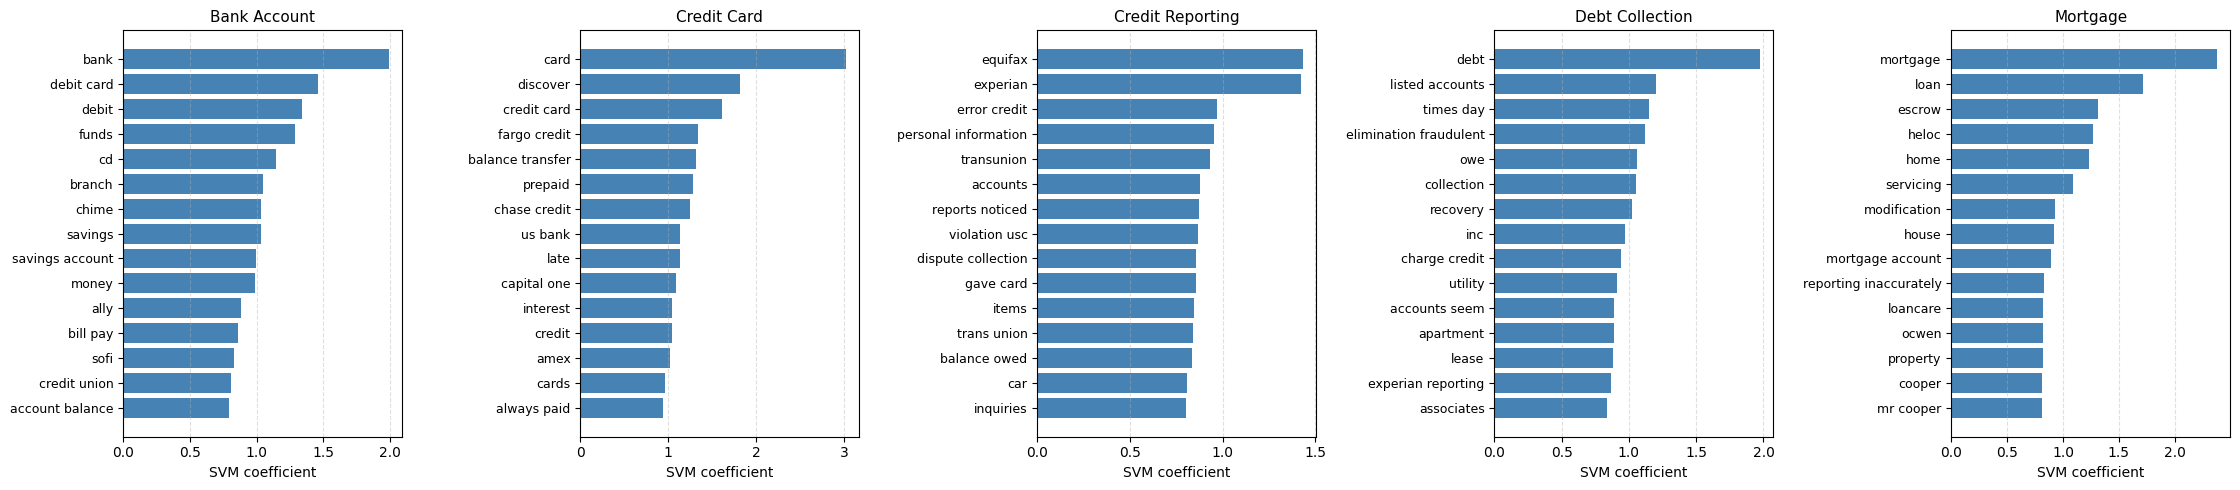

[saved] outputs\top_features_per_class.png


In [ ]:
def save_top_features(results, data):
    svm_result = next((r for r in results if r["name"] == "Linear SVM"), None)
    if svm_result is None or not hasattr(svm_result["model"], "coef_"):
        return

    model = svm_result["model"]
    n_word = len(data["tfidf_word"].get_feature_names_out())
    word_names = data["tfidf_word"].get_feature_names_out()

    lines = ["Top 15 word features per class (from Linear SVM)",
             "=" * 70]
    for i, cls in enumerate(data["labels"]):
        coefs = model.coef_[i, :n_word]
        top_idx = np.argsort(coefs)[-15:][::-1]
        lines.append(f"\n[{cls}]")
        for j in top_idx:
            lines.append(f"  {word_names[j]:<30s}  {coefs[j]:+.3f}")

    text = "\n".join(lines)
    out = OUT_DIR / "top_features_per_class.txt"
    out.write_text(text, encoding="utf-8")
    print(f"[saved] {out}\n")
    print(text)  # display inline in the notebook

    #bar chart of top features per class for visual inspection
    fig, axes = plt.subplots(1, len(data["labels"]),
                             figsize=(4.5 * len(data["labels"]), 5))
    if len(data["labels"]) == 1:
        axes = [axes]
    for ax, (i, cls) in zip(axes, enumerate(data["labels"])):
        coefs = model.coef_[i, :n_word]
        top_idx = np.argsort(coefs)[-15:][::-1]
        top_words = [word_names[j] for j in top_idx]
        top_vals = [coefs[j] for j in top_idx]
        ax.barh(range(len(top_words)), top_vals[::-1], color="steelblue")
        ax.set_yticks(range(len(top_words)))
        ax.set_yticklabels(top_words[::-1], fontsize=9)
        ax.set_title(cls, fontsize=11)
        ax.set_xlabel("SVM coefficient")
        ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "top_features_per_class.png", dpi=120, bbox_inches="tight")
    plt.show()  # display inline in the notebook
    plt.close()
    print(f"[saved] {OUT_DIR / 'top_features_per_class.png'}")

save_top_features(results, data)

In [ ]:
def save_sample_predictions(results, df_full, idx_test, labels):
    best = max(results, key=lambda r: r["accuracy"])
    df_test = df_full.iloc[idx_test].reset_index(drop=True).head(10).copy()
    df_test["predicted"] = [labels[i] for i in best["y_pred"][:10]]
    df_test["actual"] = df_test[LABEL_COL]
    df_test["narrative_preview"] = df_test[TEXT_COL].str[:150] + "..."
    sample_df = df_test[["actual", "predicted", "narrative_preview"]]
    sample_df.to_csv(OUT_DIR / "sample_predictions.csv", index=False)
    print(f"[saved] {OUT_DIR / 'sample_predictions.csv'} (from best model: {best['name']})\n")

    # Display inline in the notebook
    try:
        from IPython.display import display
        display(sample_df)
    except ImportError:
        print(sample_df.to_string(index=False))
